# Recurrent Neural Network

Historically, [there have been many attempts](https://doi.org/10.3390/ijms22041676) to develop an algorithm that can generate chemical entities with desirable properties. Many of the early methods relied on evolutionary aglorithms, but today deep neural networks have become very popular for this task. It is still not clear if one approach works better than the other. This tutorial is intended for broader audience and as an introduction to the concept of generative AI for drug design in general so advanced users might find it a little slow, but users new to the field might benefit much more. 

In this tutorial, we showcase the most basic DrugEx model, which is a simple recurrent neural network (RNN). RNNs are one of the older language models that can be adapted for molecular generation. However, there are many similar models and packages out there each with its own caveats and benefits. Therefore, it is generally a good idea to combine multiple approaches in real world applications because the overlap of the generated compounds between different methods is usually very small. DrugEx itself also provides multiple distinct methods so feel free to experiment with them as well.

## Data Acquisition 

The very first step of any computational experiment is always obtaining data. Most of the times this is the most tedious part and it pays off to spend a lot of time understanding, cleaning and refining your data set. For the sake of simplicity, we will take a few shortcuts in this tutorial, but we will try to hint at possibilities to improve the process as we go on.

### Papyrus & QSPRPred

The data used in all DrugEx tutorials comes from [Papyrus](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-022-00672-x). Papyrus is a curated data set that tries to make our lives easier by agregating publically available data under one roof and already does a few things for us, such as standardizing the compounds, aggregating and transforming activity values and giving our data overall structure that is suitable for data analysis and machine learning. However, there are also downsides to using such data set. For example, the fact that this is a curated data set means that it needs to be updated each time new information becomes available so you might not always have the most recent data to work with. In addition, sometimes the form of standardization of the data set might not be suitable for your case so you still need to spend some time reading about how the data is curated and if valuable information is not lost. For example, Papyrus does not include stereochemistry by default so if you want that kind of data (i.e. for docking), you have to retrieve it seperately. In this tutorial, we do not really have any concers about the size or the quality of the data set, but in a real world project we would.

In this tutorial, life is already made even easier for us with the provided download utility that automatically prepared and fetched the compunds we will be working with to our `data` directory:

In [1]:
import os

DATASETS_PATH = 'data/data'

os.listdir(DATASETS_PATH)

['xanthine.tsv',
 'Papyrus05.5_smiles_voc.txt',
 '.Papyrus',
 'AR_LIGANDS.tsv',
 'A2AR_LIGANDS.tsv']

We will be working with a data set of compounds related to the adenosine A2A receptor (A2AR), which will be our drug target of interest for this and all upcoming tutorials. However, if you are interested in a different target, you will typically have to assemble this data yourself. You can check out the [QSPRPred](https://github.com/CDDLeiden/QSPRPred) project that attempts to make molecular property predictions a bit easier including fetching and cleaning of data. It also provides the Papyrus integration, which was used to fetch our current data set:

In [2]:
import pandas as pd

df = pd.read_csv(f'{DATASETS_PATH}/A2AR_LIGANDS.tsv', sep='\t', header=0, na_values=('NA', 'nan', 'NaN'))
df

,Activity_ID,Quality,source,CID,SMILES,connectivity,InChIKey,InChI,InChI_AuxInfo,target_id,...,type_other,Activity_class,relation,pchembl_value,pchembl_value_Mean,pchembl_value_StdDev,pchembl_value_SEM,pchembl_value_N,pchembl_value_Median,pchembl_value_MAD
0,AACWUFIIMOHGSO_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.91968,Cc1nn(-c2cc(NC(=O)CCN(C)C)nc(-c3ccc(C)o3)n2)c(...,AACWUFIIMOHGSO,AACWUFIIMOHGSO-UHFFFAOYSA-N,InChI=1S/C19H24N6O2/c1-12-10-13(2)25(23-12)17-...,"""AuxInfo=1/1/N:1,26,22,14,15,20,19,11,12,27,6,...",P29274_WT,...,NaN,NaN,=,8.68,8.68,0.0,0.0,1.0,8.68,0.0
1,AAEYTMMNWWKSKZ_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.131451,Nc1c(C(=O)Nc2ccc([N+](=O)[O-])cc2)sc2c1cc1CCCC...,AAEYTMMNWWKSKZ,AAEYTMMNWWKSKZ-UHFFFAOYSA-N,InChI=1S/C18H16N4O3S/c19-15-13-9-10-3-1-2-4-14...,"""AuxInfo=1/1/N:22,23,21,24,8,15,9,14,19,20,7,1...",P29274_WT,...,NaN,NaN,=,4.82,4.82,0.0,0.0,1.0,4.82,0.0
2,AAGFKZWKWAMJNP_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.100375,O=C(Nc1nc2ncccc2n2c(=O)n(-c3ccccc3)nc12)c1ccccc1,AAGFKZWKWAMJNP,AAGFKZWKWAMJNP-UHFFFAOYSA-N,InChI=1S/C21H14N6O2/c28-20(14-8-3-1-4-9-14)24-...,"""AuxInfo=1/1/N:27,19,26,28,18,20,9,25,29,17,21...",P29274_WT,...,NaN,NaN,=,5.65,5.65,0.0,0.0,1.0,5.65,0.0
3,AANUKDYJZPKTKN_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.123484,CNC(=O)C12CC1C(n1cnc3c1nc(C#CCCCCC(=O)OC)nc3NC...,AANUKDYJZPKTKN,AANUKDYJZPKTKN-UHFFFAOYSA-N,InChI=1S/C28H31ClN6O5/c1-30-27(39)28-13-18(28)...,"""AuxInfo=1/1/N:1,25,18,19,17,20,35,36,34,16,21...",P29274_WT,...,NaN,NaN,=,5.45,5.45,0.0,0.0,1.0,5.45,0.0
4,AASXHCGIIQCKEE_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.419145,CCCn1c(=O)c2c(nc3cc(OC)ccn32)n(CCCNC(=O)c2ccc(...,AASXHCGIIQCKEE,AASXHCGIIQCKEE-UHFFFAOYSA-N,InChI=1S/C24H27N5O6S/c1-4-12-29-23(31)20-21(26...,"""AuxInfo=1/1/N:1,14,30,2,20,26,34,27,33,15,21,...",P29274_WT,...,NaN,NaN,=,5.2,5.20,0.0,0.0,1.0,5.20,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4077,ZYXGKENMDDPQIE_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.399078,CNc1ncc(C(=O)NCc2ccc(OC)cc2)c2nc(-c3ccco3)nn12,ZYXGKENMDDPQIE,ZYXGKENMDDPQIE-UHFFFAOYSA-N,InChI=1S/C19H18N6O3/c1-20-19-22-11-14(17-23-16...,"""AuxInfo=1/1/N:1,16,24,23,12,18,13,17,25,10,5,...",P29274_WT,...,NaN,NaN,=,7.09,7.09,0.0,0.0,1.0,7.09,0.0
4078,ZYZWFDVXMLCIOU_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.94689,Nc1nc(-c2ccco2)c2ncn(C(=O)NCCc3ccccc3)c2n1,ZYZWFDVXMLCIOU,ZYZWFDVXMLCIOU-UHFFFAOYSA-N,InChI=1S/C18H16N6O2/c19-17-22-14(13-7-4-10-26-...,"""AuxInfo=1/1/N:22,21,23,7,20,24,6,18,17,8,12,1...",P29274_WT,...,NaN,NaN,=,8.22,8.22,0.0,0.0,1.0,8.22,0.0
4079,ZZBZWSYDXUPJCT_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.131461,Nc1nc(Nc2ccc(F)cc2)nc(CSc2nnc(N)s2)n1,ZZBZWSYDXUPJCT,ZZBZWSYDXUPJCT-UHFFFAOYSA-N,InChI=1S/C12H11FN8S2/c13-6-1-3-7(4-2-6)16-11-1...,"""AuxInfo=1/1/N:8,11,7,12,15,9,6,14,2,20,4,17,1...",P29274_WT,...,NaN,NaN,=,4.89,4.89,0.0,0.0,1.0,4.89,0.0
4080,ZZMIPZLRKFEGIA_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.202018,CCCOc1ccc(C=Cc2cc3c(c(=O)n(C)c(=O)n3C)n2C)cc1,ZZMIPZLRKFEGIA,ZZMIPZLRKFEGIA-UHFFFAOYSA-N,InChI=1S/C20H23N3O3/c1-5-12-26-16-10-7-14(8-11...,"""AuxInfo=1/0/N:1,24,22,18,2,9,7,25,10,6,26,3,1...",P29274_WT,...,NaN,NaN,=,6.51,6.51,0.0,0.0,1.0,6.51,0.0


### Chemical Space Visualization

Now, we can do our first data analysis of this data set, which will be a visualization of the chemical space covered by the compounds tested against the A2A receptor in public literature. We will only be using this tool in this part of the tutorial, but it is a good idea to also use it when working with the other models in the DrugEx package. Such visualization can provide valuable insights into the generated set of compounds and put them also in context with known chemistry.

In order to map our compounds, we will use a package called `papyrus-scaffold-visualizer`, which facilitates convenient and optionally interactive plotting via with the [`molplotly`](https://github.com/wjm41/molplotly) package.

We can configure the visualization in many different ways, but for now we just want to use simple
- Morgan fingeprintsand *(molecule si break down to a arrey/vector (commonly 2,048 bits of 0s and 1s) when each position represents specific molecular substrcuture = fingerprint)*
- a t-SNE embedding *(compresing 2,048 Dimenstions to 2D, more conqrituly values of {0,1}^2048 to ℝ×ℝ )*

to show clusters of most similar compounds. We also color the points based on the pChEMBL *(affinity to a receptor)* median value extracted from the Papyrus data set

The higher this value, the more affinity/effect the compound likely has on the A2A receptor. Generally, hits with pChEMBL value of **6.5 and higher** are considered as **having significant** biological effect and/or affinity. The package uses QSPRPred data structures to make it possible to do such a plot quickly:

In [3]:
from qsprpred.data import MoleculeTable

dataset = MoleculeTable.fromTableFile(name="A2AR", filename=f'{DATASETS_PATH}/A2AR_LIGANDS.tsv')
dataset.getDF()

,Activity_ID,Quality,source,CID,SMILES,connectivity,InChIKey,InChI,InChI_AuxInfo,target_id,...,Activity_class,relation,pchembl_value,pchembl_value_Mean,pchembl_value_StdDev,pchembl_value_SEM,pchembl_value_N,pchembl_value_Median,pchembl_value_MAD,QSPRID
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2AR_0000,AACWUFIIMOHGSO_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.91968,Cc1nn(-c2cc(NC(=O)CCN(C)C)nc(-c3ccc(C)o3)n2)c(...,AACWUFIIMOHGSO,AACWUFIIMOHGSO-UHFFFAOYSA-N,InChI=1S/C19H24N6O2/c1-12-10-13(2)25(23-12)17-...,"""AuxInfo=1/1/N:1,26,22,14,15,20,19,11,12,27,6,...",P29274_WT,...,NaN,=,8.68,8.68,0.0,0.0,1.0,8.68,0.0,A2AR_0000
A2AR_0001,AAEYTMMNWWKSKZ_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.131451,Nc1c(C(=O)Nc2ccc([N+](=O)[O-])cc2)sc2c1cc1CCCC...,AAEYTMMNWWKSKZ,AAEYTMMNWWKSKZ-UHFFFAOYSA-N,InChI=1S/C18H16N4O3S/c19-15-13-9-10-3-1-2-4-14...,"""AuxInfo=1/1/N:22,23,21,24,8,15,9,14,19,20,7,1...",P29274_WT,...,NaN,=,4.82,4.82,0.0,0.0,1.0,4.82,0.0,A2AR_0001
A2AR_0002,AAGFKZWKWAMJNP_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.100375,O=C(Nc1nc2ncccc2n2c(=O)n(-c3ccccc3)nc12)c1ccccc1,AAGFKZWKWAMJNP,AAGFKZWKWAMJNP-UHFFFAOYSA-N,InChI=1S/C21H14N6O2/c28-20(14-8-3-1-4-9-14)24-...,"""AuxInfo=1/1/N:27,19,26,28,18,20,9,25,29,17,21...",P29274_WT,...,NaN,=,5.65,5.65,0.0,0.0,1.0,5.65,0.0,A2AR_0002
A2AR_0003,AANUKDYJZPKTKN_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.123484,CNC(=O)C12CC1C(n1cnc3c1nc(C#CCCCCC(=O)OC)nc3NC...,AANUKDYJZPKTKN,AANUKDYJZPKTKN-UHFFFAOYSA-N,InChI=1S/C28H31ClN6O5/c1-30-27(39)28-13-18(28)...,"""AuxInfo=1/1/N:1,25,18,19,17,20,35,36,34,16,21...",P29274_WT,...,NaN,=,5.45,5.45,0.0,0.0,1.0,5.45,0.0,A2AR_0003
A2AR_0004,AASXHCGIIQCKEE_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.419145,CCCn1c(=O)c2c(nc3cc(OC)ccn32)n(CCCNC(=O)c2ccc(...,AASXHCGIIQCKEE,AASXHCGIIQCKEE-UHFFFAOYSA-N,InChI=1S/C24H27N5O6S/c1-4-12-29-23(31)20-21(26...,"""AuxInfo=1/1/N:1,14,30,2,20,26,34,27,33,15,21,...",P29274_WT,...,NaN,=,5.2,5.20,0.0,0.0,1.0,5.20,0.0,A2AR_0004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2AR_4077,ZYXGKENMDDPQIE_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.399078,CNc1ncc(C(=O)NCc2ccc(OC)cc2)c2nc(-c3ccco3)nn12,ZYXGKENMDDPQIE,ZYXGKENMDDPQIE-UHFFFAOYSA-N,InChI=1S/C19H18N6O3/c1-20-19-22-11-14(17-23-16...,"""AuxInfo=1/1/N:1,16,24,23,12,18,13,17,25,10,5,...",P29274_WT,...,NaN,=,7.09,7.09,0.0,0.0,1.0,7.09,0.0,A2AR_4077
A2AR_4078,ZYZWFDVXMLCIOU_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.94689,Nc1nc(-c2ccco2)c2ncn(C(=O)NCCc3ccccc3)c2n1,ZYZWFDVXMLCIOU,ZYZWFDVXMLCIOU-UHFFFAOYSA-N,InChI=1S/C18H16N6O2/c19-17-22-14(13-7-4-10-26-...,"""AuxInfo=1/1/N:22,21,23,7,20,24,6,18,17,8,12,1...",P29274_WT,...,NaN,=,8.22,8.22,0.0,0.0,1.0,8.22,0.0,A2AR_4078
A2AR_4079,ZZBZWSYDXUPJCT_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.131461,Nc1nc(Nc2ccc(F)cc2)nc(CSc2nnc(N)s2)n1,ZZBZWSYDXUPJCT,ZZBZWSYDXUPJCT-UHFFFAOYSA-N,InChI=1S/C12H11FN8S2/c13-6-1-3-7(4-2-6)16-11-1...,"""AuxInfo=1/1/N:8,11,7,12,15,9,6,14,2,20,4,17,1...",P29274_WT,...,NaN,=,4.89,4.89,0.0,0.0,1.0,4.89,0.0,A2AR_4079


Plotting itself can then be done on a few lines:

In [4]:
from qsprpred.data.descriptors.fingerprints import MorganFP
from scaffviz.clustering.manifold import TSNE
from scaffviz.depiction.plot import Plot

# calculate descriptors
dataset.addDescriptors([MorganFP( radius=3, nBits=2048)], recalculate=False, )

In [5]:
# plot the map of chemical space
plt = Plot(TSNE())
plt.plot(
    dataset,
    color_by="pchembl_value_Median",
    interactive=False,
    color_continuous_scale="rdylgn",
)

You can also make the plot an interactive web application:

In [6]:
# plot the map of chemical space
#plt = Plot(TSNE())
#plt.plot(
#    dataset,
#    color_by="pchembl_value_Median",
#    interactive=True,
#    card_data=["pchembl_value_Median", "source"],
#    port=9292,
#    viewport_height=800,
#    color_continuous_scale="rdylgn"
#)

This plot you are seeing is running as a seperate web application embedded into this one. So if you are running this notebook on [localhost:8888](http://localhost:8888), you can navigate to [localhost:9292](http://localhost:9090) to see te full depiction on its own page. You should be able to see clusters of similar molecules and regions of chemical space with active/inactive molecules should be discernible. Therefore, such visualization could be useful to assess how many molecules of what activity we have in the data set and get an idea how similar they are to each other. It is also possible to identify potential activity cliffs (regions where very similar molecules have vastly different activity).

## Transfer Learning (Pretrained & Finetuned Model)

We will not be training a generative model from scratch in this tutorial, but instead we will use a common technique called *transfer learning*. In transfer learning, we use an already pretrained model for one task as a starting point to finetune a second model for another task. The workflow is illustrated below:

![TL](images/TL.drawio.svg)

In the context of this tutorial, the pretrained model will be a large model trained on a large data set ([Papyrus](https://github.com/OlivierBeq/Papyrus-scripts)). The task of this model was to observe the entirety of Papyrus data set and learn what a chemical structure looks like and be able to generate chemically valid molecules that resemble known chemistry. For this tutorial, we chose the model based on recurrent neural networks (RNNs). These are usually easier to train so you can run these experiments on a regular GPU that you might have at home without too much waiting. This choice will also affect all other choices we will make in this tutorial so note that for a different model, slightly different workflow would be necessary.

This global pretrained model is not very useful for our task, however, because it will likely only be able to generate very small percentage of molecules that might have some activity on the A2A receptor. Therefore, we will use the concept of transfer learning to obtain a finetuned model that can both generate valid molecules, but make those molecules much more similar to those that we extracted previously and should be relevant to the A2A receptor. 

### Pre-trained Model
First, let us start by loading and testing the pretrained model. This model is [archived on the Zenodo service](https://zenodo.org/record/7378923). There are many files archived along with the model, but at this point we only care about the `.vocab` and `.pkg` files:

In [7]:
import os
from drugex.training.generators import SequenceRNN
from drugex.data.corpus.vocabulary import VocSmiles

MODELS_PR_PATH = "data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT/"
GPUS = [0] # we will use only one GPU with ID=0, but if you have more, you can list more GPU IDs here

voc = VocSmiles.fromFile(os.path.join(MODELS_PR_PATH, "Papyrus05.5_smiles_rnn_PT.vocab"), encode_frags=False)
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(os.path.join(MODELS_PR_PATH, "Papyrus05.5_smiles_rnn_PT.pkg"))

The `RNN` model requires a vocabulary of tokens to be provided. You can open this file and see the tokens defined in it. These are the words of the SMILES language that we use to define structures of molecules. What the model learned is how to combine these words into viable sentences (chemical structures) in the SMILES language. The data saved in the `.pkg` file are the weights (learned states) of the model that define the learned parameters and tell the model how to combine the tokens in the vocabulary in the correct way to generate a random compound that resembles known chemistry.

At this point, we should have the pretrained model loaded and be ready to generate some molecules with it. We can validate that the model functions as expected by sampling a small number of molecules from it:

In [8]:
generated = pretrained.generate(num_samples=100)
generated

Generating molecules:   0%|          | 0/100 [00:00<?, ?it/s]

,SMILES,Valid
0,Cn1nnnc1Sc1nnc(N)nc1N,1.0
1,CC(=NNc1nc(-c2cc3cc(Br)ccc3o2)cs1)C1CC1,1.0
2,CCN(CC)C(=O)C(=O)C(Cc1ccc(C(F)(F)F)cc1)NC(=O)c...,1.0
3,NC(=O)C1(N2CCCCC2)CCN(C(=S)Nc2cccc(F)c2)CC1,1.0
4,Cc1ccc(-c2nc3ncccc3o2)cc1NC(=O)c1ccc(Br)cc1,1.0
...,...,...
95,O=S1(=O)NC(c2ccc(Br)cc2)=CC(c2ccc3ccn(Cc4ccc(F...,1.0
96,O=C(Nc1cc([N+](=O)[O-])ccc1Cl)c1cc(S(=O)(=O)N2...,1.0
97,CC(S)=NCCCCC(NC(=O)CCc1ccccc1)C(=O)N1CCC2(CC1)...,1.0
98,CCOC(=O)COc1ccn2c(-c3ccccc3)c(-c3ccc(C4(N)CCC4...,1.0


It is a little hard to read into the structures from just a crude list of SMILES, but we can also show them as a table thanks to the `smilesToGrid` functions in the `utils` module in the current directory:

In [9]:
from utils import smilesToGrid

smilesToGrid(generated.SMILES, molsPerRow=5, n_rows=5)

### Finetuned Model

As you can see, the pretrained model produces a wide variety of compounds. Generating more concrete and more defined chemical space will be the task for the finetuned model, which we will train with transfer learning. We will bias the model to generate structures that resemble more the structures in our A2A data set introduced previously:

In [10]:
df

,Activity_ID,Quality,source,CID,SMILES,connectivity,InChIKey,InChI,InChI_AuxInfo,target_id,...,type_other,Activity_class,relation,pchembl_value,pchembl_value_Mean,pchembl_value_StdDev,pchembl_value_SEM,pchembl_value_N,pchembl_value_Median,pchembl_value_MAD
0,AACWUFIIMOHGSO_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.91968,Cc1nn(-c2cc(NC(=O)CCN(C)C)nc(-c3ccc(C)o3)n2)c(...,AACWUFIIMOHGSO,AACWUFIIMOHGSO-UHFFFAOYSA-N,InChI=1S/C19H24N6O2/c1-12-10-13(2)25(23-12)17-...,"""AuxInfo=1/1/N:1,26,22,14,15,20,19,11,12,27,6,...",P29274_WT,...,NaN,NaN,=,8.68,8.68,0.0,0.0,1.0,8.68,0.0
1,AAEYTMMNWWKSKZ_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.131451,Nc1c(C(=O)Nc2ccc([N+](=O)[O-])cc2)sc2c1cc1CCCC...,AAEYTMMNWWKSKZ,AAEYTMMNWWKSKZ-UHFFFAOYSA-N,InChI=1S/C18H16N4O3S/c19-15-13-9-10-3-1-2-4-14...,"""AuxInfo=1/1/N:22,23,21,24,8,15,9,14,19,20,7,1...",P29274_WT,...,NaN,NaN,=,4.82,4.82,0.0,0.0,1.0,4.82,0.0
2,AAGFKZWKWAMJNP_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.100375,O=C(Nc1nc2ncccc2n2c(=O)n(-c3ccccc3)nc12)c1ccccc1,AAGFKZWKWAMJNP,AAGFKZWKWAMJNP-UHFFFAOYSA-N,InChI=1S/C21H14N6O2/c28-20(14-8-3-1-4-9-14)24-...,"""AuxInfo=1/1/N:27,19,26,28,18,20,9,25,29,17,21...",P29274_WT,...,NaN,NaN,=,5.65,5.65,0.0,0.0,1.0,5.65,0.0
3,AANUKDYJZPKTKN_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.123484,CNC(=O)C12CC1C(n1cnc3c1nc(C#CCCCCC(=O)OC)nc3NC...,AANUKDYJZPKTKN,AANUKDYJZPKTKN-UHFFFAOYSA-N,InChI=1S/C28H31ClN6O5/c1-30-27(39)28-13-18(28)...,"""AuxInfo=1/1/N:1,25,18,19,17,20,35,36,34,16,21...",P29274_WT,...,NaN,NaN,=,5.45,5.45,0.0,0.0,1.0,5.45,0.0
4,AASXHCGIIQCKEE_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.419145,CCCn1c(=O)c2c(nc3cc(OC)ccn32)n(CCCNC(=O)c2ccc(...,AASXHCGIIQCKEE,AASXHCGIIQCKEE-UHFFFAOYSA-N,InChI=1S/C24H27N5O6S/c1-4-12-29-23(31)20-21(26...,"""AuxInfo=1/1/N:1,14,30,2,20,26,34,27,33,15,21,...",P29274_WT,...,NaN,NaN,=,5.2,5.20,0.0,0.0,1.0,5.20,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4077,ZYXGKENMDDPQIE_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.399078,CNc1ncc(C(=O)NCc2ccc(OC)cc2)c2nc(-c3ccco3)nn12,ZYXGKENMDDPQIE,ZYXGKENMDDPQIE-UHFFFAOYSA-N,InChI=1S/C19H18N6O3/c1-20-19-22-11-14(17-23-16...,"""AuxInfo=1/1/N:1,16,24,23,12,18,13,17,25,10,5,...",P29274_WT,...,NaN,NaN,=,7.09,7.09,0.0,0.0,1.0,7.09,0.0
4078,ZYZWFDVXMLCIOU_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.94689,Nc1nc(-c2ccco2)c2ncn(C(=O)NCCc3ccccc3)c2n1,ZYZWFDVXMLCIOU,ZYZWFDVXMLCIOU-UHFFFAOYSA-N,InChI=1S/C18H16N6O2/c19-17-22-14(13-7-4-10-26-...,"""AuxInfo=1/1/N:22,21,23,7,20,24,6,18,17,8,12,1...",P29274_WT,...,NaN,NaN,=,8.22,8.22,0.0,0.0,1.0,8.22,0.0
4079,ZZBZWSYDXUPJCT_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.131461,Nc1nc(Nc2ccc(F)cc2)nc(CSc2nnc(N)s2)n1,ZZBZWSYDXUPJCT,ZZBZWSYDXUPJCT-UHFFFAOYSA-N,InChI=1S/C12H11FN8S2/c13-6-1-3-7(4-2-6)16-11-1...,"""AuxInfo=1/1/N:8,11,7,12,15,9,6,14,2,20,4,17,1...",P29274_WT,...,NaN,NaN,=,4.89,4.89,0.0,0.0,1.0,4.89,0.0
4080,ZZMIPZLRKFEGIA_on_P29274_WT,High,ChEMBL31,ChEMBL31.compound.202018,CCCOc1ccc(C=Cc2cc3c(c(=O)n(C)c(=O)n3C)n2C)cc1,ZZMIPZLRKFEGIA,ZZMIPZLRKFEGIA-UHFFFAOYSA-N,InChI=1S/C20H23N3O3/c1-5-12-26-16-10-7-14(8-11...,"""AuxInfo=1/0/N:1,24,22,18,2,9,7,25,10,6,26,3,1...",P29274_WT,...,NaN,NaN,=,6.51,6.51,0.0,0.0,1.0,6.51,0.0


There is a lot of data in this table, but for our transfer learning exercise only the SMILES column is important:

In [11]:
smiles_train = df.SMILES
smiles_train

0       Cc1nn(-c2cc(NC(=O)CCN(C)C)nc(-c3ccc(C)o3)n2)c(...
1       Nc1c(C(=O)Nc2ccc([N+](=O)[O-])cc2)sc2c1cc1CCCC...
2        O=C(Nc1nc2ncccc2n2c(=O)n(-c3ccccc3)nc12)c1ccccc1
3       CNC(=O)C12CC1C(n1cnc3c1nc(C#CCCCCC(=O)OC)nc3NC...
4       CCCn1c(=O)c2c(nc3cc(OC)ccn32)n(CCCNC(=O)c2ccc(...
                              ...                        
4077       CNc1ncc(C(=O)NCc2ccc(OC)cc2)c2nc(-c3ccco3)nn12
4078           Nc1nc(-c2ccco2)c2ncn(C(=O)NCCc3ccccc3)c2n1
4079                Nc1nc(Nc2ccc(F)cc2)nc(CSc2nnc(N)s2)n1
4080        CCCOc1ccc(C=Cc2cc3c(c(=O)n(C)c(=O)n3C)n2C)cc1
4081             CCOC(=O)c1cnc(NCC(C)C)n2nc(-c3ccco3)nc12
Name: SMILES, Length: 4082, dtype: str

In order to train the finetuned model, we need to first standardize and prepare the SMILES strings. DrugEx has its own utility to do that for all its models:

In [12]:
from drugex.data.processing import Standardization

N_PROCESSES = 12 # number of CPU cores to use
CHUNK_SIZE = 1000 # largest chunk per CPU core (regulates RAM usage)

standardizer = Standardization(n_proc=N_PROCESSES, chunk_size=CHUNK_SIZE)
smiles_train = standardizer.apply(smiles_train)
smiles_train[0:10]

Standardizing molecules (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

['Cc1cc(C)n(-c2cc(NC(=O)CCN(C)C)nc(-c3ccc(C)o3)n2)n1',
 'Nc1c(C(=O)Nc2ccc([N+](=O)[O-])cc2)sc2nc3c(cc12)CCCC3',
 'O=C(Nc1nc2ncccc2n2c(=O)n(-c3ccccc3)nc12)c1ccccc1',
 'CNC(=O)C12CC1C(n1cnc3c(NCc4cccc(Cl)c4)nc(C#CCCCCC(=O)OC)nc31)C(O)C2O',
 'CCCn1c(=O)c2c(nc3cc(OC)ccn32)n(CCCNC(=O)c2ccc(S(C)(=O)=O)cc2)c1=O',
 'Cn1c(-n2nccn2)nc2c(N)nc(CCc3ccccc3)nc21',
 'Nc1nc(-c2ccccc2)cn2cc(-c3ccco3)nc12',
 'CCCn1c(=O)c2c(nc3n2CCCN3c2ccc(OCCN3CCCC3)cc2)n(CCC)c1=O',
 'N#Cc1c(-c2ccccc2)cc(-c2ccco2)nc1N',
 'CCCn1c(=O)c2nc(-c3ccccc3)[nH]c2n(CCCOC)c1=O']

We write the list of SMILES back into `smiles_train` because we will not need the original SMILES anymore and proceed to generate our training data sets. In this step, the so called 'corpus' data set is generated that is nothing more than the SMILES separated into words/tokens according to the given vocabulary. You can check out the `ligand_corpus.tsv` for yourself and see there really is nothing too special about it. The code is a little verbose, but that comes mostly from the way the data is handled by parallel processes to take advantage of multiple CPUs:

In [13]:
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.datasets import SmilesDataSet
from drugex.logs import logger
import os
logger.setLevel('ERROR')

DATA_DIR = "data/datasets/encoded/rnn/"
os.makedirs(DATA_DIR, exist_ok=True)

voc = VocSmiles.fromFile(f"{MODELS_PR_PATH}/Papyrus05.5_smiles_rnn_PT.vocab", encode_frags=False)
encoder = CorpusEncoder( # CorpusEcoder uses the supplied corpus class to encode tokens for the new data set
    SequenceCorpus, # The corpus class implements how each SMILES string is divided into words by the vocabulary
    {
        # arguments of the SequenceCorpus
        'vocabulary': voc, # used vocabulary
        'update_voc': False, # if False, the vocabulary stays fixed (no new tokens are added to it)
        'throw': True # compounds containing unknown tokens are thrown out of the resulting data set

    },
    n_proc=N_PROCESSES,
    chunk_size=CHUNK_SIZE
)

data_collector = SmilesDataSet(os.path.join(DATA_DIR, 'ligand_corpus.tsv'), rewrite=True)
encoder.apply(smiles_train, collector=data_collector)

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

In this scenario, we will also compile a test/validation set of compounds. This will help us identify when the model starts to loose its ability to generate diverse and/or valid chemistry and begins overfitting on the training set. While we do want the generated structures to look like those in the training data, we also do not want them to be exactly the same. The validation set will serve as an indicator of such behaviour and the model will know to stop the training once the performance starts to deteriorate. 

In this case, we choose to select 10% (or a maximum of 10,000) compounds to the test set. We save the training and test set to separate files and we also save the vocabulary for safe keeping (we did not modify the original vocabulary in any way, but it is a good idea to save it anyway for future reference): 

In [14]:
splitter = RandomTrainTestSplitter(0.1, 1e4)
train, test = splitter(data_collector.getData())
for data, name in zip([train, test], ['train', 'test']):
    pd.DataFrame(data, columns=data_collector.getColumns()).to_csv(os.path.join(DATA_DIR, f'ligand_{name}.tsv'), header=True, index=False, sep='\t')

voc.toFile(os.path.join(DATA_DIR, 'pretrained.vocab'))

Now, we wrap our training and test set to `SmilesDataSet` instances so that we can generate data loaders for training:

In [15]:
BATCH_SIZE = 256

data_set_train = SmilesDataSet(os.path.join(DATA_DIR, 'ligand_train.tsv'), voc=voc)
train_loader = data_set_train.asDataLoader(batch_size=BATCH_SIZE)

data_set_test = SmilesDataSet(os.path.join(DATA_DIR, 'ligand_test.tsv'), voc=voc)
valid_loader = data_set_test.asDataLoader(batch_size=BATCH_SIZE)

Data loaders are a data structure used by [PyTorch](https://pytorch.org/) library for deep learning, which DrugEx uses to handle data and define models. They are responsible for batching the data so that it can be offloaded to the GPU for training because the whole data set would not be able to fit. In addition, batch size is an important hyperparameter in neural networks. The training does not proceed sample by sample, but rather the model processes each batch at a time and adjusts its parameters only after passing the whole batch through the network. This helps to save computational resources, but also affects the training process because it sometimes also has influence on how often and how significantly the model parameters are adjusted. Therefore, choosing the correct batch size is someting we might want play around with during training.

Another term commonly used in the language of neural networks is an 'epoch'. It is simply one iteration of training during which the model goes through all the batches and, thus, the whole data set. It is usual after each epoch that we evaluate the performance of the model and decided if it needs further training or not. In this case, we set up our training as follows:

In [16]:
from drugex.training.monitors import FileMonitor

MODEL_DIR = "data/models/finetuned/rnn"

ft_path = os.path.join(MODEL_DIR, 'a2ar_finetuned')
finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
finetuned.loadStatesFromFile(os.path.join(MODELS_PR_PATH, 'Papyrus05.5_smiles_rnn_PT.pkg'))
monitor = FileMonitor(ft_path, save_smiles=True, reset_directory=True)
finetuned.fit(train_loader, valid_loader, epochs=10, monitor=monitor)

voc.toFile(os.path.join(MODEL_DIR, 'finetuned.vocab'))

Fitting model:   0%|          | 0/10 [00:00<?, ?it/s]

Facilitating transfer learning in this case is easy. We load the pretrained model just like we did above, but instead of generating smiles with it, we call the `fit` method and supply the finetuning data loaders. We set the number of epochs to 10 in this case. Training should not take more than an hour. In this case, even on an older laptop GPU (NVIDIA RTX 2070) this took less than a minute. This is a big advantage of this older approach. For all the other models within DrugEx, more computational power is needed.

You can notice that we also set up a training monitor (`FileMonitor`), which saves some important data during training. You will find these files in the `MODEL_DIR` directory with the `ligand_finetune` prefix. The following file saves the training and validation loss (`loss_train` and `loss_valid`, respectively). In simple terms, the losses indicate how well the model is able to capture the probability distribution of tokens in either the training set or the test set with the compounds it generates at each epoch. We also get information about the percentage of valid SMILES it produces (`valid_ratio`). There are also some empty values that are not relevant at the moment, but will come into play later. We can load the table as any other data file:

In [17]:
df_info = pd.read_csv(f'{MODEL_DIR}/a2ar_finetuned_fit.tsv', sep='\t')
df_info.head()

,Epoch,loss_train,loss_valid,valid_ratio,best_epoch
0,1,77.699,0.663,0.449,1
1,2,21.541,0.221,0.322,2
2,3,16.141,0.183,0.588,3
3,4,13.700,0.172,0.707,4
4,5,13.254,0.166,0.777,5


We can also plot everything quite easily:

<Axes: >

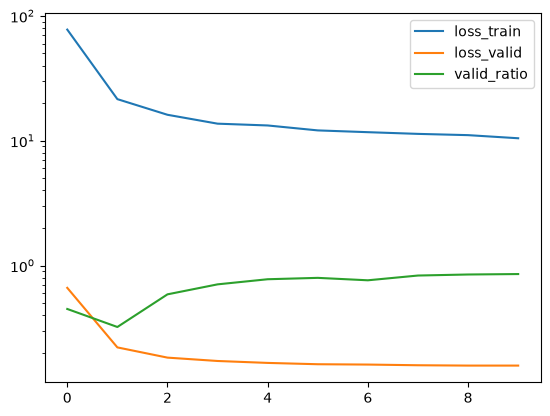

In [18]:
df_info[['loss_train', 'loss_valid', 'valid_ratio']].plot.line(logy=True)

We can see that while the training loss is going down during training the validation loss starts to dwindle and even increases slightly. This indicates that our model is starting to overfit the training set a little so we might want to think about tweaking the parameters a little bit here.

With `Filemonitor` `save_model_option` set to `best` (default), the model will only be save on the epoch with the lowest validation loss (i.e. best_epoch in the table above). It is possible to use the `patience` parameter in the `fit` method to stop training early if the validation loss does not improve for a certain number of epochs to reduce training time.

In the plot above, we can see the the ratio of valid molecules (valid_ratio) initially decreases before increasing again. In some trainingsets the epoch with the lowest validation loss may be found while the valid_ratio is still increasing. It might be desirable to continue training for a few more epochs in this case. For this it is possible to use the `loss_tolerance` argument, to allow a minimal increase in validation loss if the valid_ratio is higher. For example, with `loss_tolerance` set to 0.02, if at epoch 10 the validation loss is 0.148 with a valid_ratio of 0.701 and at epoch 11 the validation loss is 0.149 with a valid_ratio of 0.800, epoch 11 will be `best_epoch`.

However, this is OK for the purpose of our tutorial and as we will see, even such a short round of transfer learning had an effect on our model. We can again take a peek at the generated smiles:

In [19]:
finetuned.loadStatesFromFile(f'{MODEL_DIR}/a2ar_finetuned.pkg')
generated = finetuned.generate(num_samples=100)
smilesToGrid(generated.SMILES)

Generating molecules:   0%|          | 0/100 [00:00<?, ?it/s]

When we compare these molecules to those generated by the pretrained model, it is already clear that these compounds are differently distributed and if we take a look at the structures we might be able to spot some patterns commonly seen in adenosine receptor ligands (check out the interactive chemical space plot above). So our transfer learning approoach did seem to work and if we trained for more epochs, we would probably be able to get more similar and more plausible structures.

### Optimizing Compound Properties with Reinforcement Learning

We now successfully used transfer learning to create a model that can generate new molecules that resemble known data. That is very nice, but not often useful. Consider for example a case of a pharmaceutical company that is trying to develop a new drug, which has not been published or patented, yet. It is unlikely that with this model, we will be able to find completely new scaffolds. All it can do is copy and mimick known chemical space related to adenosine receptor A2A. It also has no information about activity of the compounds. It just creates new molecule that look like the known ligands. But what if we could create a model that can generate structures that are more likely to be binders than nonbinders of the A2A receptor? We will explain how to do exactly that in this chapter.

Reinforcement learning is a well-known concept in machine learning and AI and can be used to train neural networks to successfully accomplish various tasks. The most famous example is [AlphaGo](https://en.wikipedia.org/wiki/AlphaGo), a machine learning model that was trained to successfully play the borad game Go, but there are also models that learned to [walk](https://arxiv.org/pdf/1812.11103.pdf), [play computer games](https://www.theverge.com/2018/8/6/17655086/dota2-openai-bots-professional-gaming-ai) or many [other things](https://rl-book.com/applications/). This is a simple schematic that illustrates the idea of reinforcement learning:

![RL](https://upload.wikimedia.org/wikipedia/commons/1/1b/Reinforcement_learning_diagram.svg)

Picture Credit: [WikiMedia Commons](https://commons.wikimedia.org/wiki/File:Reinforcement_learning_diagram.svg), Megajuice

Regardless of whether the AI is learning to walk or generate molecules, the concept is the same. The model acts as an *agent* in the *environment*. The agent performs an *action* in the environment (i.e. generates a molecular structure). Based on the action, the agent then receives a *reward* from an *interpreter* (i.e. a QSAR model predicting activity on the A2A receptor). The obtained reward can then be used to adjust the actions made by the agant, for example by changing it's *state* (i.e. the weights of the neural network). This loop is repeated until the agent learns to walk, play a game or generates molecules interesting for us. 

In this tutorial, we will teach our model (*agent*) to generate more active and synthetically accessible molecules. That means we will have two *observers* in our environment that will each give feedback to our models. This is called multi-objective optimization and reflects more the way we think about 'good molecules' in drug discovery. It is not always just perceived activity that is important, but other criteria like synthetic accessibility play an important role too.

#### Observer 1 (The QSAR Model)

Therefore, the first of our observers (or more often called 'objective functions') will be a QSAR model predicting biological activity. It will provide the *agent* with information about the likely activity against the A2A receptor. In [qsar.ipynb](qsar.ipynb), you will find the code used to obtain this model. But thanks to the download utility, we also already have direct access to it and can load it with QSPRPred: 

In [20]:
from qsprpred.models.scikit_learn import SklearnModel

predictor = SklearnModel(
    name='A2AR_RandomForestClassifier',
    base_dir='./data/models/qsar'
)

In order to feed this model to our DrugEx agent, we need to wrap it in the already prepared `Scorer`:

In [21]:
from drugex.training.scorers.qsprpred import QSPRPredScorer

qsprpred_scorer = QSPRPredScorer(predictor)

A scorer is a simple Python class that needs to have the `getScores` and `getKey` methods. The `getScores` method is the most important one and is used to calculate scores (model predictions) for the generated molecules at each epoch of training. The `getKey` method just gives the scorer a unique name that will appear in the outputs and will be used by the model. It is simple to implement if you ever need to integrate other models with DrugEx. Here is a simple example of how your own scorer could look like:

In [22]:
from drugex.training.scorers.interfaces import Scorer

class ModelScorer(Scorer):
    
    def __init__(self, *args, **kwargs):
        super().__init__()
        pass
    
    def getScores(self, mols, frags=None):
        """
        Processes molecules and returns a score for each (i.e. a QSAR model prediction).
        """
        
        return [0] * len(mols) # just return zero for all molecules for the sake of example
    
    def getKey(self):
        """
        Unique Identifier among all the scoring functions used in a single environment.
        """
        
        return "ScorerName"

We can now easily calculate the scores for our generated molecules above:

In [23]:
predictions = pd.Series(qsprpred_scorer.getScores(generated.SMILES))
predictions

0     0.320
1     0.472
2     0.864
3     0.544
4     0.548
      ...  
95    0.968
96    0.260
97    0.988
98    0.976
99    0.420
Length: 100, dtype: float64

We can also calculate the percentage of molecules that would be classified as active at this point. It is just molecules for which the predicted value is more than 0.5:

In [24]:
sum(predictions > 0.5) / len(predictions)

0.55

Therefore, some generated molecules are perceived as likely binders by our model. Not bad for such a simple model. But let's see if we can further improve this ratio with reinforcement learning.

#### Observer 2 (Synthetic Accessibility Score)

You probably already noticed that the model sometimes outputs very weird structures. It usually gets better with more training and more data, but we can also counteract this with synthetic accessibility scoring. Therefore, our second observer in this experiment will be the [Synthetic Accessibility Score](https://jcheminf.biomedcentral.com/articles/10.1186/1758-2946-1-8) (SAScore). It has been around for a long time and is generally considered as a reasonable measure of how complex (hard to synthesize) a compound structure is, even despite some shortcomings. It is available in DrugEx and we can easily create this scoring function as follows:

In [25]:
from drugex.training.scorers.properties import Property

sascore = Property("SA")

#### Desirability Score Modifiers

Because the scorers that we created above each work on a different scale, it might be a good idea to normalize them somehow and make them work on the same scale and express to the model what values of the scores are actually desirable and what are not. For example, we want the SAScore as low as possible while we want the score from the model as close to 1 as possible (have the most confidence in the prediction that the generated compounds are active). This where the desirability modifier comes in. It helps us to keep things on one scale while telling the model what distribution of scores is good for us.

For the QSAR model, we will choose the `ClippedScore` modifier:

In [26]:
from drugex.training.scorers.modifiers import ClippedScore

qsprpred_scorer.setModifier(ClippedScore(lower_x=0.2, upper_x=0.8))

With this modifier we are telling the agent that molecules with scores that are less than 0.2 are no good for us while scores of more than 0.8 are good with some linear progressin in between. We can easily visualize the modifier with the following code:

In [27]:
qsprpred_scorer.getModifier()

<Axes: xlabel='Score', ylabel='Clipped Score'>

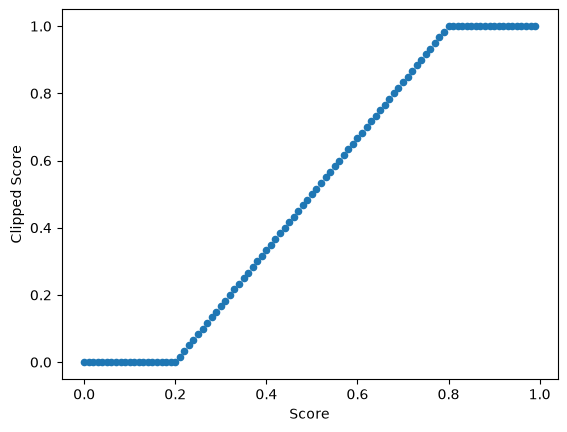

In [28]:
import numpy as np

def depict_modifier(modifier, start=0, end=1, step=0.01, name = 'Clipped Score'):
    vals = np.arange(start,end, step)
    scores = [(x, modifier(x)) for x in vals] # get the A1R modifier for inactivity (the lower the activity, the higher the reward)
    scores = pd.DataFrame(scores, columns=['Score', name])
    return scores.plot.scatter(x = 'Score', y = name)

depict_modifier(qsprpred_scorer.getModifier())

As we can see the agent will be told to stay away from molecules of scores lower then 0.2 and move towards molecules of at least score 0.8. The reason for the linear progression in between is there so that the model can evaluate whether one molecule is better than the other, but not generally desired.

For the SAScore we will opt for the smoothed out variant of clipped score, `SmoothClippedScore`:

In [29]:
from drugex.training.scorers.modifiers import SmoothClippedScore

sascore.setModifier(SmoothClippedScore(lower_x=5, upper_x=3))

This funtion looks as follows:

<Axes: xlabel='Score', ylabel='Clipped Score - Smooth'>

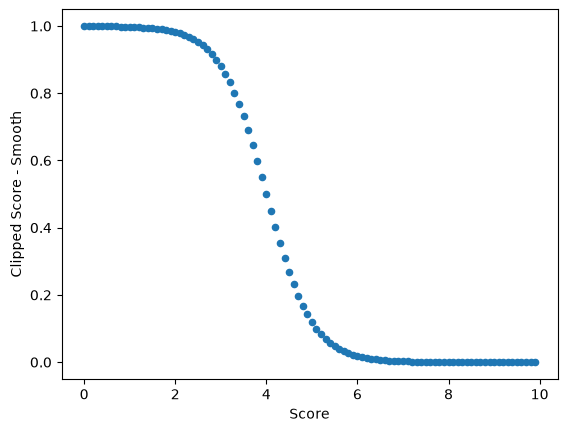

In [30]:
depict_modifier(sascore.getModifier(), 0, 10, 0.1, 'Clipped Score - Smooth')

In general, molecules with SAScore higher than 6 are considered quite complex, but can still be present in data sets so we give the distribution a more gradual decrease with a longer right tail. We will also never achieve the perfect SAScore of 1, but that is OK as long as we tell the model we want the score as close to one as possible.

#### The Environment

The last thing we have to do is to create the environment and to specify desirability thresholds for our scoring functions. We also need to apply a suitable multi-objective reward scheme:

In [31]:
from drugex.training.environment import DrugExEnvironment
from drugex.training.rewards import ParetoCrowdingDistance

scorers = [
    qsprpred_scorer,
    sascore
]
thresholds = [
    0.5,
    0.1
]

environment = DrugExEnvironment(scorers, thresholds, reward_scheme=ParetoCrowdingDistance())

The thresholds can play some role in some reward schemes (i.e. `WeightedSum`), but in this case they will just be used to deem whether a molecule is desirable or not. We can show what that means if we get the scores for our previously generated compounds with the environment: 

In [32]:
scores = environment.getScores(generated.SMILES.to_list())
scores

,Valid,QSPRpred_A2AR_RandomForestClassifier,SA,Desired
0,1.0,0.200000,0.978462,0
1,1.0,0.453333,0.935354,0
2,1.0,1.000000,0.937580,1
3,1.0,0.573333,0.924681,1
4,1.0,0.580000,0.965566,1
...,...,...,...,...
95,1.0,1.000000,0.931523,1
96,1.0,0.100000,0.962023,0
97,1.0,1.000000,0.952424,1
98,1.0,1.000000,0.939208,1


You can easily compare this to the unmodified scores:

In [33]:
environment.getUnmodifiedScores(generated.SMILES.to_list())

,QSPRpred_A2AR_RandomForestClassifier,SA
0,0.320,2.091909
1,0.472,2.664004
2,0.864,2.645288
3,0.544,2.746140
4,0.548,2.333169
...,...,...
95,0.968,2.694840
96,0.260,2.383976
97,0.988,2.501658
98,0.976,2.631211


The `DESIRE` column shows a 1 for all molecules that satisfy the desirability thresholds for all objectives (SAScore higher than 0.1 and the predicted active probability from QSAE of more than 0.5). Note that the thresholds relate to the modified scores and not the original values.

We can now calculate how many desirable compounds there are in this initial set:

In [34]:
sum(scores["Desired"]) / len(scores)

0.55

We can also analyze the distribution of the score for each objective:

<Axes: >

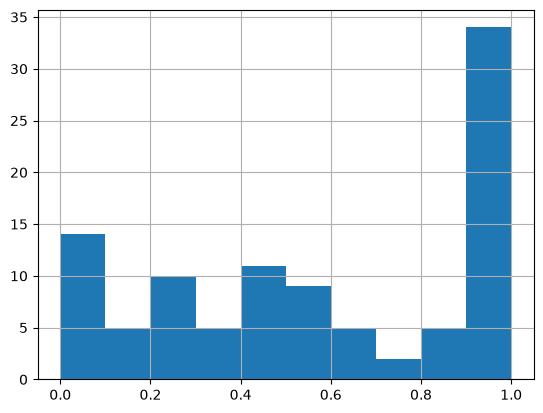

In [35]:
scores.QSPRpred_A2AR_RandomForestClassifier.hist()

<Axes: >

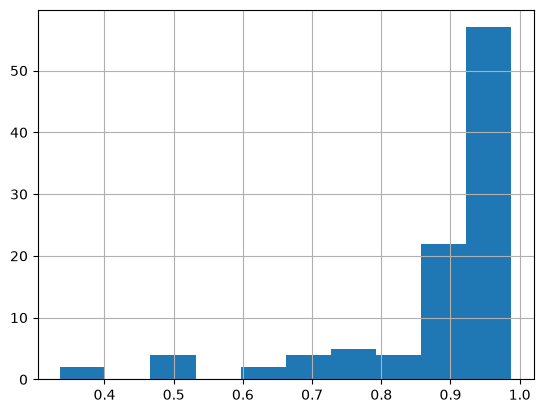

In [36]:
scores.SA.hist()

We can see that this is not bad for just an initial model, but we can surely do better, especially when it comes to biological activity predictions. Let's see if we can manage that with reinforcement learning. For the RNN model, the reinforcement learning framework is implemented with the `SmilesExplorerNoFrag` class:

In [37]:
from drugex.training.explorers import SequenceExplorer
import warnings
warnings.filterwarnings('ignore')

pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PR_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')

finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
finetuned.loadStatesFromFile(f'{MODEL_DIR}/a2ar_finetuned.pkg')

explorer = SequenceExplorer(
    agent = finetuned,
    env = environment,
    mutate = pretrained, # network introducing "random mutations" to the generated structures (rate determined by epsilon)
    epsilon = 0.1,
    use_gpus = GPUS
)

There are quite a few things we can tweak about the explorer here and the way it approaches reinforcement learning. We could for example choose the pretrained network to be the agent instead of the finetuned network. Doing that could help us find more novel structures that are also active. When using the finetuned model as the agent, the structures will be more similar to known ligands. In our current scenario, we are also using a rather low exploration parameter (`epsilon`), which is another way to influence the diversity of the generated compounds. The higher the `epsilon`, the larger the influence of the mutations introduced by the pretrained model, which adds more randomness to our structures. In short, there is a lot of space for experimentation and you can read more information in the [original paper](https://doi.org/10.1186/s13321-019-0355-6). In this particular case, we just chose the easiest setup for the algorithm so that it converges more easily and we can train it faster, but at the expense of more diverse exploration of chemical space.

With that said, let's get to training. Thanks to this simplified setup, 30 epochs should be enough for us to already see a result:

In [38]:
MODEL_DIR_RL = "./data/models/RL/rnn"

monitor = FileMonitor(os.path.join(MODEL_DIR_RL, 'a2ar_agent'), save_smiles=True, reset_directory=True)
explorer.fit(monitor=monitor, epochs=30)

Fitting SMILES RNN explorer:   0%|          | 0/30 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

...

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating policy gradient...:   0%|          | 0/8 [00:00<?, ?it/s]

Again, we can observe the evolution of certain parameters during training. Most importantly the validity of the generated structures and the training loss:

In [39]:
df_info = pd.read_csv(f'{MODEL_DIR_RL}/a2ar_agent_fit.tsv', sep='\t')
df_info.head()

,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.29,0.29,0.09,0.629,0.568,3.868,1
1,2,0.56,0.56,0.21,0.683,0.633,5.666,2
2,3,0.64,0.64,0.20,0.652,0.597,7.395,2
3,4,0.64,0.64,0.14,0.624,0.553,9.739,2
4,5,0.77,0.77,0.16,0.610,0.554,7.791,2


<Axes: >

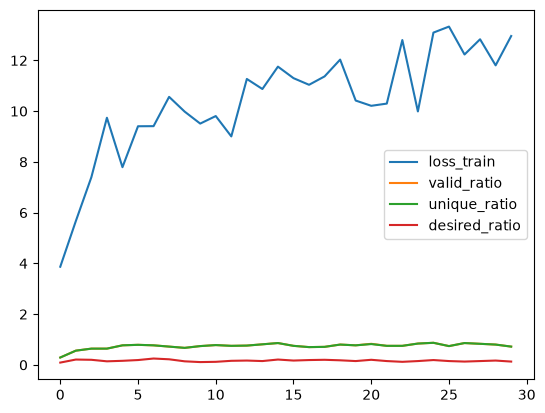

In [40]:
df_info[['loss_train', 'valid_ratio','unique_ratio', 'desired_ratio']].plot.line()

We can see that most of the compounds remain valid and the training loss also stabilizes after an initial increase. Therefore, if we kept training this model for a bit longer we would probably get stable improvement in loss while keeping the generated molecules unique and valid.

But let's test if this model is now able to produce better molecules from the point of view of our objectives. We just need to load it from the saved state and sample new structures:

In [41]:
agent = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
agent.loadStatesFromFile(f'{MODEL_DIR_RL}/a2ar_agent.pkg')

generated = agent.generate(num_samples=100)
generated

Generating molecules:   0%|          | 0/100 [00:00<?, ?it/s]

,SMILES,Valid
0,O=C(COc1ccc(Cl)cc1)c1ccc(-c2cc3ccccc3o2)cc1,1.0
1,NCC1CCn2c1cc1ccc(Cl)cc12,1.0
2,O=C(c1cc(Cl)cc(Cl)c1)c1cn(C(c2ccccc2)c2ccccc2)...,1.0
3,C=S(O)(O)=C1CCN(c2nc(CN)nc3sc4c(c23)CC(C)(C)CC...,1.0
4,COCCOc1ccc(C(=O)NC(C(=O)NCc2ccccc2C)C(C)C)cc1,1.0
...,...,...
95,CC(Cc1cccc(-c2nc(C(C)(C)C)[nH]c2C(=O)NCc2ccc(C...,1.0
96,CNC(=O)C(C)Oc1ccc(F)c(C(C)Nc2nccc(N3C(=O)C(OC(...,1.0
97,CC(C)Nc1nc2cc(Cl)c(Cl)cc2nc1Cl,1.0
98,CS(=O)(=O)N1CCC(OCc2cn(-c3cccc(O)n3)nn2)CC1,1.0


We can again push them through our environment and see how many of them are desirable according to our settings:

In [42]:
scores = environment.getScores(generated.SMILES)
scores

,Valid,QSPRpred_A2AR_RandomForestClassifier,SA,Desired
0,1.0,0.533333,0.986382,1
1,1.0,0.360000,0.860860,0
2,1.0,0.340000,0.962254,0
3,1.0,0.420000,0.445384,0
4,1.0,0.486667,0.962930,0
...,...,...,...,...
95,1.0,0.520000,0.920525,1
96,1.0,0.413333,0.460108,0
97,1.0,0.173333,0.961379,0
98,1.0,0.260000,0.897548,0


In [43]:
sum(scores["Desired"] > 0.5) / len(scores)

0.23

<Axes: >

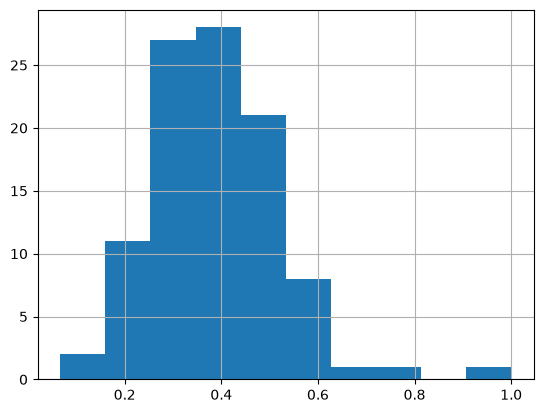

In [44]:
scores.QSPRpred_A2AR_RandomForestClassifier.hist()

<Axes: >

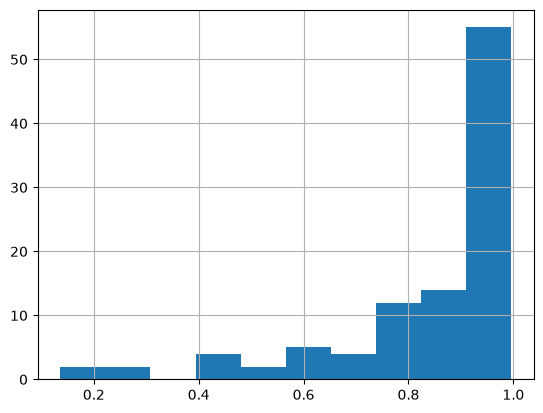

In [45]:
scores.SA.hist()

That definitely looks better than before. We now have a much higher ratio of desirable molecules. Let's take a look at the structures and use the model output to color them based on predicted activity:

In [46]:
dataset = MoleculeTable("A2AR_agent", df=generated)
dataset.addProperty(qsprpred_scorer.getKey(), scores[qsprpred_scorer.getKey()].values)
dataset.addDescriptors(
    [MorganFP(radius=3, nBits=2048)]
)

plt = Plot(TSNE())
plt.plot(
    dataset,
    color_by=qsprpred_scorer.getKey(),
    interactive=False,
    color_continuous_scale="rdylgn"
)

A lot of the molecules are lit up green, which is good. It means the model is confident that these structures belong to active ligands. If we optimized for a bit longer, the ratio of presumably active molecules would probably keep improving.

But let's be critical of what we accomplished here for a moment. We merely optimized the original finetuned model so it is likely there is a big overlap between the original data set and this new set of compounds. We can easily check how our compounds compare to the original set by visualizing them together:

In [47]:
df_joined = pd.concat(
    [
        pd.DataFrame(
            {'SMILES' : df.SMILES.tolist(), 'Group': 'A2A Set'}
        ),
        pd.DataFrame(
            {'SMILES' : generated.SMILES, 'Group': 'Generated'}
        )
    ]
)
df_joined

,SMILES,Group
0,Cc1nn(-c2cc(NC(=O)CCN(C)C)nc(-c3ccc(C)o3)n2)c(...,A2A Set
1,Nc1c(C(=O)Nc2ccc([N+](=O)[O-])cc2)sc2c1cc1CCCC...,A2A Set
2,O=C(Nc1nc2ncccc2n2c(=O)n(-c3ccccc3)nc12)c1ccccc1,A2A Set
3,CNC(=O)C12CC1C(n1cnc3c1nc(C#CCCCCC(=O)OC)nc3NC...,A2A Set
4,CCCn1c(=O)c2c(nc3cc(OC)ccn32)n(CCCNC(=O)c2ccc(...,A2A Set
...,...,...
A2AR_agent_095,CC(Cc1cccc(-c2nc(C(C)(C)C)[nH]c2C(=O)NCc2ccc(C...,Generated
A2AR_agent_096,CNC(=O)C(C)Oc1ccc(F)c(C(C)Nc2nccc(N3C(=O)C(OC(...,Generated
A2AR_agent_097,CC(C)Nc1nc2cc(Cl)c(Cl)cc2nc1Cl,Generated
A2AR_agent_098,CS(=O)(=O)N1CCC(OCc2cn(-c3cccc(O)n3)nn2)CC1,Generated


Indeed, there is some overlap between the original data set and the generated structures, but we also manage to generate some compounds outside of these orginal clusters. You can try to vary the `epsilon` parameter and see what happens with desirability and diversity of the molecules. However, maybe there is also some merit to this model. It all depends on the task at hand.

In [48]:
dataset = MoleculeTable(name="A2AR_joined", df=df_joined)
dataset.addDescriptors(
    [MorganFP(radius=3, nBits=2048)]
)

plt = Plot(TSNE())
plt.plot(
    dataset,
    recalculate=False,
    color_by='Group',
    interactive=False
)